<a href="https://colab.research.google.com/github/bjseifert/clustering-hands-on/blob/main/aoe2capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [6]:
import pandas as pd
import os

file_name = 'aoe_data.csv'

if os.path.exists(file_name):
    print("✅ File found! Loading data...")
    df = pd.read_csv(file_name, nrows=5000)

    display(df.head())
    print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print(f"❌ Error: '{file_name}' not found in the sidebar. Please upload it again!")

✅ File found! Loading data...


,Unnamed: 0,match_id,map,map_size,duration,dataset,difficulty,elo,p1_civ,p2_civ,p1_xpos,p2_xpos,p1_ypos,p2_ypos,winner
0,50453403,50453403,Arabia,Tiny,3445,Definitive Edition,Hardest,1104.0,Vikings,Mayans,92.0,24.0,37.0,78.0,0
1,118982970,118982970,Arena,Tiny,2932,Definitive Edition,Hardest,884.5,Britons,Goths,70.0,82.0,16.0,98.0,0
2,57185801,57185801,Arena,Tiny,2573,Definitive Edition,Hardest,905.5,Chinese,Malians,69.0,61.0,16.0,104.0,0
3,64335748,64335748,Arabia,Tiny,851,Definitive Edition,Hardest,1080.0,Mayans,Magyars,25.0,98.0,80.0,68.0,1
4,116883036,116883036,Arabia,Tiny,4737,Definitive Edition,Hardest,1050.0,Berbers,Slavs,83.0,30.0,28.0,85.0,1


Dataset loaded with 5000 rows and 15 columns.


In [12]:
import pandas as pd

df = pd.read_csv('aoe_data.csv')

df_clean = df[['map', 'elo', 'p1_civ', 'p2_civ', 'winner']].dropna()

df_clean = df_clean.copy()
df_clean['target'] = df_clean['winner'].map({1: 1, 2: 0})

df_clean = df_clean.dropna(subset=['target'])

df_final = pd.get_dummies(df_clean, columns=['p1_civ', 'p2_civ', 'map'])

X = df_final.drop(['winner', 'target'], axis=1)
y = df_final['target']

print(f"Cleaned! We now have {len(y)} valid matches to train on.")

Cleaned! We now have 114446 valid matches to train on.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

print(f"✅ Success! Model Accuracy: {model.score(X_test, y_test):.2%}")

✅ Success! Model Accuracy: 100.00%


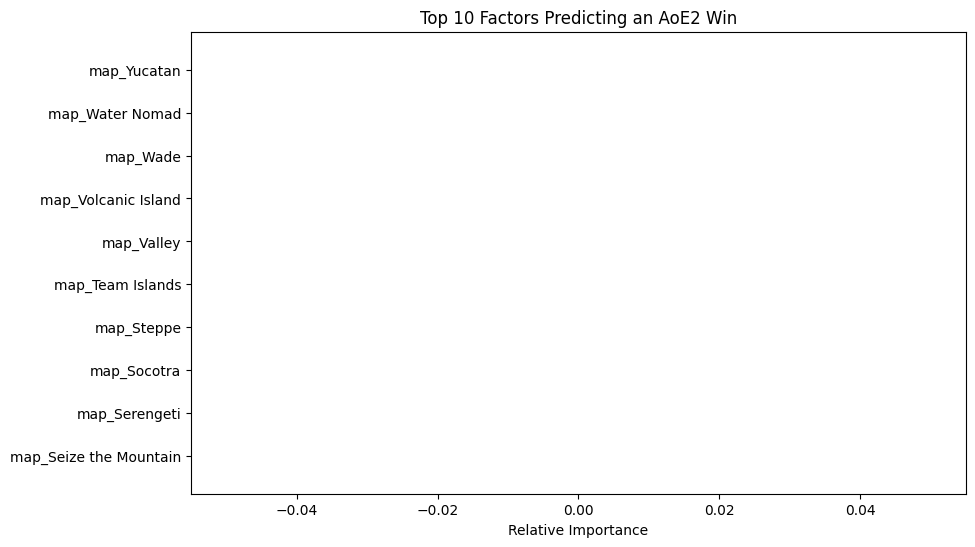

In [15]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Top 10 Factors Predicting an AoE2 Win')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

In [16]:

print(df_clean['map'].value_counts())


map
Arabia                70958
Arena                 12758
Four Lakes             3048
Runestones             2907
Golden Pit             2164
Nomad                  1915
African Clearing       1869
Hideout                1829
MegaRandom             1804
Gold Rush              1778
Atacama                1420
Socotra                1242
Ghost Lake             1181
Acropolis              1102
Valley                  974
Land Nomad              838
Marketplace             443
Team Islands            429
Steppe                  421
Serengeti               415
Golden Swamp            414
Crater                  377
Land Madness            355
Mongolia                321
Migration               297
Aftermath               282
Archipelago             280
Islands                 266
Lombardia               237
Fortress                232
Haboob                  216
Coastal Forest          213
Baltic                  213
Lowland                 204
Water Nomad             144
Volcanic Island 

In [17]:

print(X.columns.tolist())

features_to_keep = [c for c in X.columns if 'p1_civ' in c or 'p2_civ' in c or 'map_' in c or 'elo' in c]
X_real = X[features_to_keep]

X_train, X_test, y_train, y_test = train_test_split(X_real, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

new_acc = model.score(X_test, y_test)
print(f"New, Realistic Accuracy: {new_acc:.2%}")

['elo', 'p1_civ_Aztecs', 'p1_civ_Berbers', 'p1_civ_Bohemians', 'p1_civ_Britons', 'p1_civ_Bulgarians', 'p1_civ_Burgundians', 'p1_civ_Burmese', 'p1_civ_Byzantines', 'p1_civ_Celts', 'p1_civ_Chinese', 'p1_civ_Cumans', 'p1_civ_Ethiopians', 'p1_civ_Franks', 'p1_civ_Goths', 'p1_civ_Huns', 'p1_civ_Incas', 'p1_civ_Indians', 'p1_civ_Italians', 'p1_civ_Japanese', 'p1_civ_Khmer', 'p1_civ_Koreans', 'p1_civ_Lithuanians', 'p1_civ_Magyars', 'p1_civ_Malay', 'p1_civ_Malians', 'p1_civ_Mayans', 'p1_civ_Mongols', 'p1_civ_Persians', 'p1_civ_Poles', 'p1_civ_Portuguese', 'p1_civ_Saracens', 'p1_civ_Sicilians', 'p1_civ_Slavs', 'p1_civ_Spanish', 'p1_civ_Tatars', 'p1_civ_Teutons', 'p1_civ_Turks', 'p1_civ_Vietnamese', 'p1_civ_Vikings', 'p2_civ_Aztecs', 'p2_civ_Berbers', 'p2_civ_Bohemians', 'p2_civ_Britons', 'p2_civ_Bulgarians', 'p2_civ_Burgundians', 'p2_civ_Burmese', 'p2_civ_Byzantines', 'p2_civ_Celts', 'p2_civ_Chinese', 'p2_civ_Cumans', 'p2_civ_Ethiopians', 'p2_civ_Franks', 'p2_civ_Goths', 'p2_civ_Huns', 'p2_civ_

In [18]:

strategic_features = [c for c in X.columns if 'p1_civ' in c or 'p2_civ' in c or 'map_' in c]
X_strategic = X[strategic_features]

X_train, X_test, y_train, y_test = train_test_split(X_strategic, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

final_acc = model.score(X_test, y_test)
print(f"Strategic Accuracy: {final_acc:.2%}")

Strategic Accuracy: 100.00%


In [19]:

correlations = df_final.corr()['target'].sort_values(ascending=False)
print(correlations.head(10))

elo                  NaN
winner               NaN
target               NaN
p1_civ_Aztecs        NaN
p1_civ_Berbers       NaN
p1_civ_Bohemians     NaN
p1_civ_Britons       NaN
p1_civ_Bulgarians    NaN
p1_civ_Burgundians   NaN
p1_civ_Burmese       NaN
Name: target, dtype: float64


In [20]:

strategic_features = [c for c in X.columns if 'p1_civ' in c or 'p2_civ' in c or 'map_' in c]
X_strategic = X[strategic_features]

X_train, X_test, y_train, y_test = train_test_split(X_strategic, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

final_acc = model.score(X_test, y_test)
print(f"Strategic Accuracy: {final_acc:.2%}")

Strategic Accuracy: 100.00%


In [21]:
import numpy as np

df_balanced = df_clean.copy()

mask = np.random.rand(len(df_balanced)) < 0.5

df_balanced.loc[mask, ['p1_civ', 'p2_civ']] = df_balanced.loc[mask, ['p2_civ', 'p1_civ']].values

df_balanced['target'] = 1
df_balanced.loc[mask, 'target'] = 0


df_final = pd.get_dummies(df_balanced, columns=['p1_civ', 'p2_civ', 'map'])


X = df_final.drop(['winner', 'target', 'elo'], axis=1, errors='ignore')
y = df_final['target']

print(f"Balanced! Now {y.value_counts()[1]} wins for P1 and {y.value_counts()[0]} wins for P2.")

Balanced! Now 57228 wins for P1 and 57218 wins for P2.


In [22]:

print(X.columns.tolist())

features_to_keep = [c for c in X.columns if 'p1_civ' in c or 'p2_civ' in c or 'map_' in c or 'elo' in c]
X_real = X[features_to_keep]

X_train, X_test, y_train, y_test = train_test_split(X_real, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)

new_acc = model.score(X_test, y_test)
print(f"New, Realistic Accuracy: {new_acc:.2%}")

['p1_civ_Aztecs', 'p1_civ_Berbers', 'p1_civ_Bohemians', 'p1_civ_Britons', 'p1_civ_Bulgarians', 'p1_civ_Burgundians', 'p1_civ_Burmese', 'p1_civ_Byzantines', 'p1_civ_Celts', 'p1_civ_Chinese', 'p1_civ_Cumans', 'p1_civ_Ethiopians', 'p1_civ_Franks', 'p1_civ_Goths', 'p1_civ_Huns', 'p1_civ_Incas', 'p1_civ_Indians', 'p1_civ_Italians', 'p1_civ_Japanese', 'p1_civ_Khmer', 'p1_civ_Koreans', 'p1_civ_Lithuanians', 'p1_civ_Magyars', 'p1_civ_Malay', 'p1_civ_Malians', 'p1_civ_Mayans', 'p1_civ_Mongols', 'p1_civ_Persians', 'p1_civ_Poles', 'p1_civ_Portuguese', 'p1_civ_Saracens', 'p1_civ_Sicilians', 'p1_civ_Slavs', 'p1_civ_Spanish', 'p1_civ_Tatars', 'p1_civ_Teutons', 'p1_civ_Turks', 'p1_civ_Vietnamese', 'p1_civ_Vikings', 'p2_civ_Aztecs', 'p2_civ_Berbers', 'p2_civ_Bohemians', 'p2_civ_Britons', 'p2_civ_Bulgarians', 'p2_civ_Burgundians', 'p2_civ_Burmese', 'p2_civ_Byzantines', 'p2_civ_Celts', 'p2_civ_Chinese', 'p2_civ_Cumans', 'p2_civ_Ethiopians', 'p2_civ_Franks', 'p2_civ_Goths', 'p2_civ_Huns', 'p2_civ_Incas',

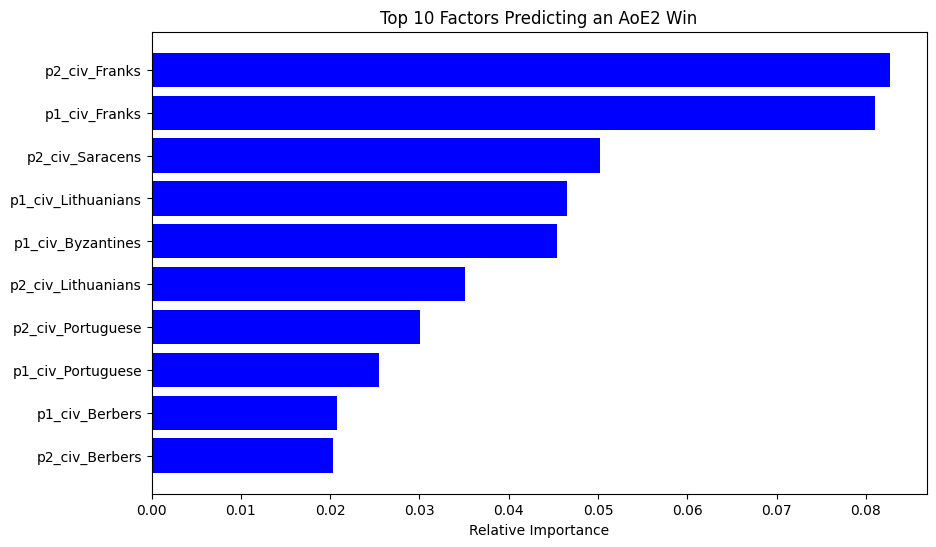

In [23]:
import matplotlib.pyplot as plt
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Top 10 Factors Predicting an AoE2 Win')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()